<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Clustering_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [30]:
# Load dataset properly by skipping the descriptive header rows
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name='data', skiprows=0) # Trying default first
# If standard format, the data is often in a sheet named 'data'
# Let's check sheet names if this fails, but usually skipping rows is key.
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name=1)
display(df.head())

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  18 non-null     object
 1   Unnamed: 1                                                                             13 non-null     object
 2   Unnamed: 2                                                                             6 non-null      object
 3   Unnamed: 3                                                                             13 non-null     object
 4   Unnamed: 4                                                                             18 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [15]:
import pandas as pd

# Skip the first few rows that contain text descriptions
df = pd.read_excel("EastWestAirlines.xlsx", skiprows=1)

# Inspect again
print(df.head())
print(df.dtypes)


  flying patterns, earning and use of frequent flyer rewards, and use of the airline credit  \
0  card.  The task is to identify customer segmen...                                          
1                                                NaN                                          
2                                                NaN                                          
3  Source: Based upon real business data; company...                                          
4             (c) 2016 Galit Shmueli and Peter Bruce                                          

  Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4  
0        NaN        NaN        NaN        NaN  
1        NaN        NaN        NaN        NaN  
2        NaN        NaN        NaN        NaN  
3        NaN        NaN        NaN        NaN  
4        NaN        NaN        NaN        NaN  
flying patterns, earning and use of frequent flyer rewards, and use of the airline credit    object
Unnamed: 1                               

In [31]:
# Clean and prepare the full numeric dataset
df_numeric = df.drop(columns=['ID#'], errors='ignore')
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
df_numeric = df_numeric.fillna(df_numeric.median())

print(f'New shape: {df_numeric.shape}')
display(df_numeric.head())

New shape: (3999, 11)


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


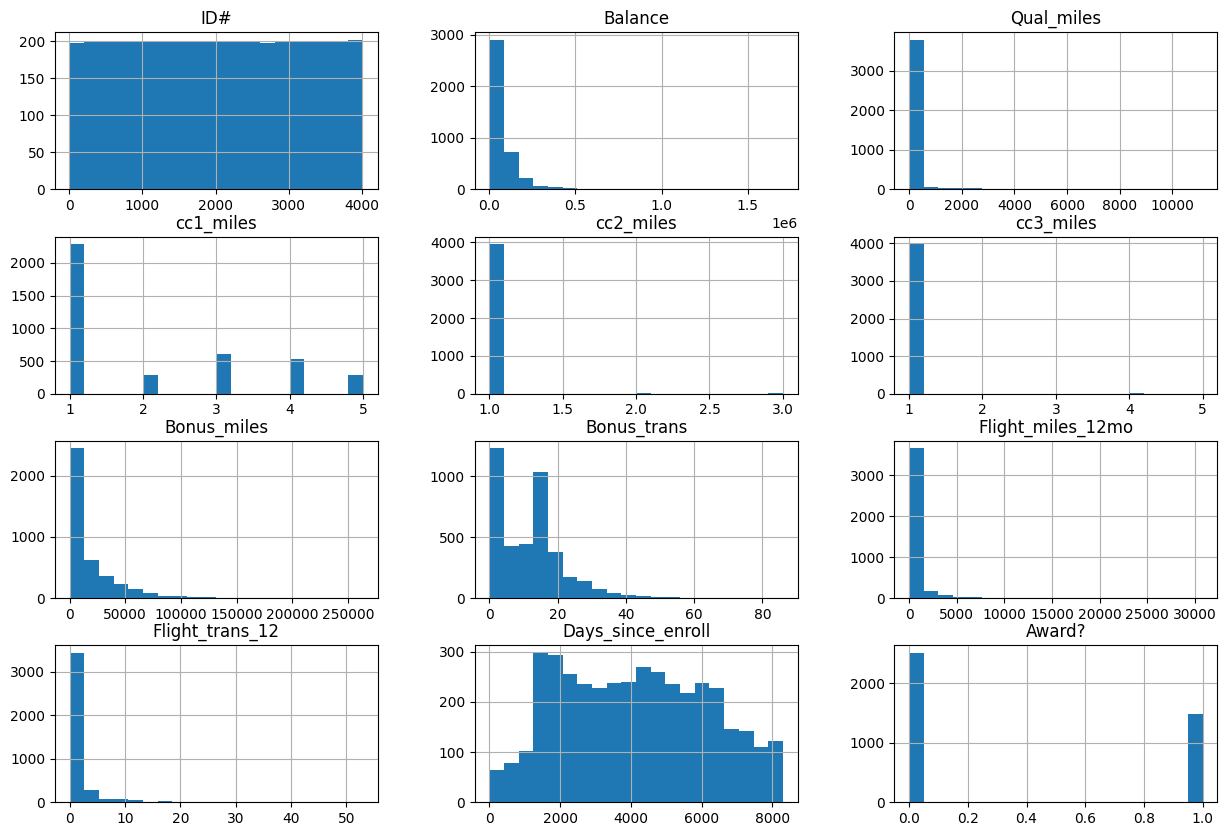

In [38]:
# Histograms
df.hist(bins=20, figsize=(15,10))
plt.show()


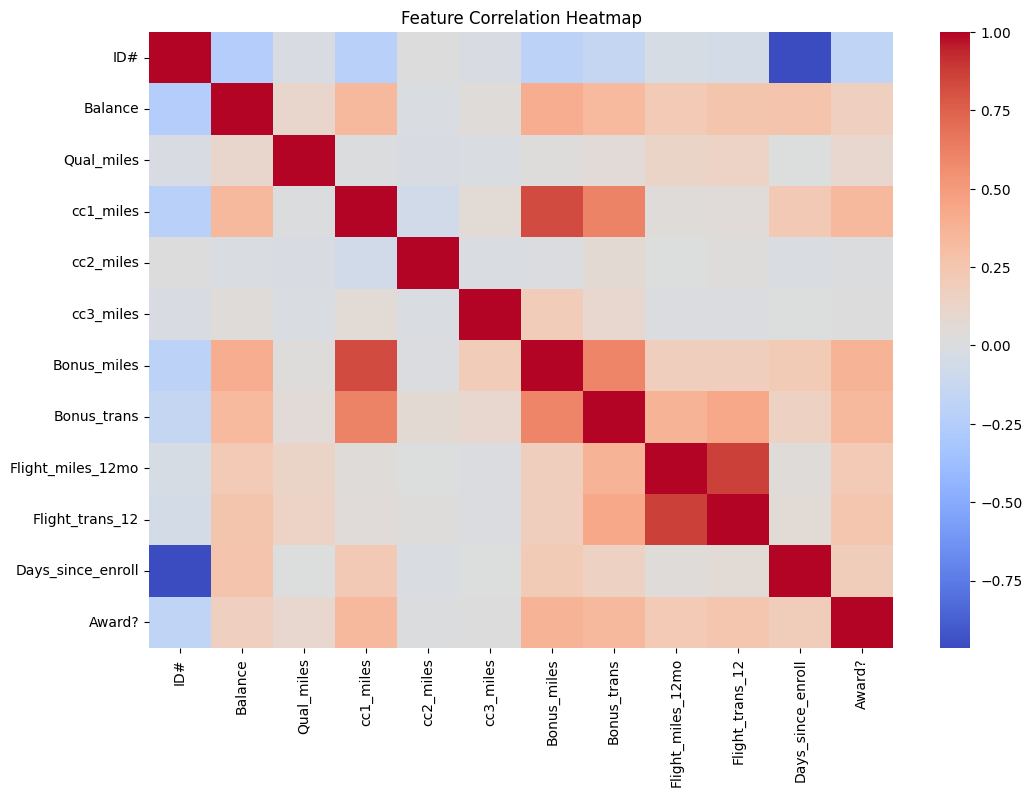

In [40]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f"Scaled data shape: {X_scaled.shape}")

Scaled data shape: (3999, 11)


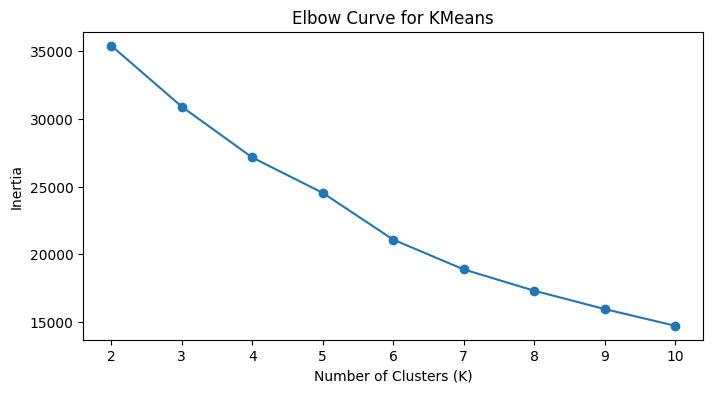

Silhouette Score (KMeans K=5): 0.3189


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for KMeans")
plt.show()

# Choosing K=5 for initial segmentation
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score (KMeans K=5): {silhouette_score(X_scaled, labels_kmeans):.4f}")

DBSCAN found 2 clusters.


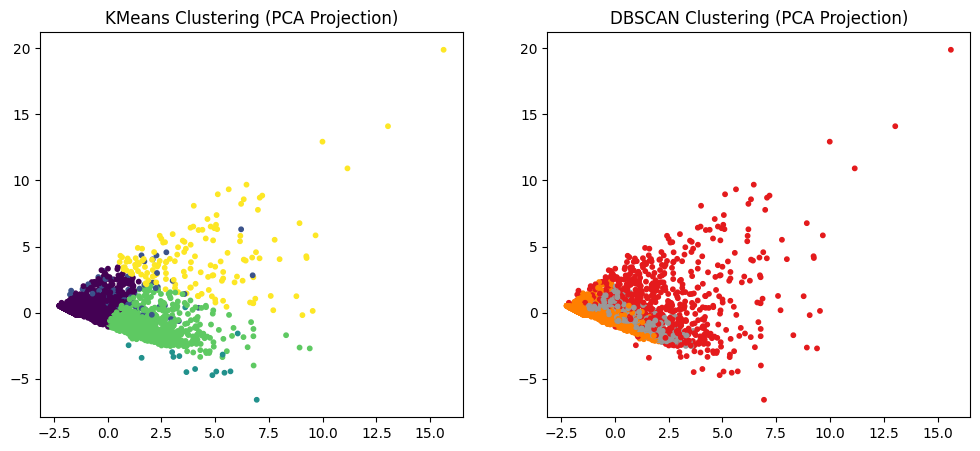

In [35]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

dbscan = DBSCAN(eps=1.0, min_samples=12)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print(f"DBSCAN found {n_clusters} clusters.")

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', s=10)
plt.title("KMeans Clustering (PCA Projection)")

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='Set1', s=10)
plt.title("DBSCAN Clustering (PCA Projection)")
plt.show()

In [36]:
import numpy as np

print("KMeans cluster counts:", np.bincount(labels_kmeans))
print("DBSCAN cluster counts:", np.bincount(labels_dbscan[labels_dbscan >= 0]))

print("\nInsights:")
print("- KMeans creates balanced clusters but assumes spherical shapes.")
print("- DBSCAN detects dense regions and noise (-1 label).")


KMeans cluster counts: [2532   61   15 1244  147]
DBSCAN cluster counts: [2266 1022]

Insights:
- KMeans creates balanced clusters but assumes spherical shapes.
- DBSCAN detects dense regions and noise (-1 label).
